# Brain Tumor Classification from MRI Scans — a CNN-based EfficientNet Model Architecture

**MD. JADID HOSSAIN SANIM**
  **ID: 1000129287**

---

## Assignment Overview

Here for the Assignment-01, I have chosen  image classification on a medical image analysis model using a Convolutional Neural Network
(CNN)-based architecture known as EfficientNet B0.


### Dataset Details:
  Brain Tumor MRI Dataset (from Kaggle)
Here is the link of the dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

The dataset contains 7,200 human brain MRI images categorized into four classes:

( Glioma,
Meningioma,
Pituitary tumor,
No tumor.)






The dataset is structured into training and testing sets with balanced class distributions.

Dataset Structure
Training:
    glioma/        (1400 images)
    meningioma/    (1400 images)
    pituitary/     (1400 images)
    notumor/       (1400 images)

Testing/
    glioma/        (400 images)
    meningioma/    (400 images)
    pituitary/     (400 images)
    notumor/       (400 images)




### Anti-overfitting strategy ( that we used here)

augmentation matched to MRI physics·
dropout in the head·
decoupled weight decay·
label smoothing·
frozen-backbone warm-up·
LR scheduling·
early stopping with best checkpoint restore

---
## 1. Import Libraries


In [18]:
import os
import math
import time
import random
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

---
## 2. Dataset Loading

The dataset is fetched directly from Kaggle with kagglehub.

In [19]:
if importlib.util.find_spec('kagglehub') is None:
    os.system('pip install -q kagglehub')
import kagglehub

DATASET_SLUG = 'masoudnickparvar/brain-tumor-mri-dataset'

def resolve_data_root():
    root = kagglehub.dataset_download(DATASET_SLUG)

    if os.path.isdir(os.path.join(root, 'Training')):
        return root
    for dirpath, dirnames, _ in os.walk(root):
        if 'Training' in dirnames:
            return dirpath
    raise FileNotFoundError('Could not locate a folder containing Training after download.')

DATA_ROOT = resolve_data_root()
print('Dataset root:', DATA_ROOT)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset root: /kaggle/input/brain-tumor-mri-dataset


## 2.1 Dataset Structure

In [20]:
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
DISPLAY_NAMES = {'glioma': 'Glioma', 'meningioma': 'Meningioma',
                 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}
NUM_CLASSES = len(CLASS_NAMES)
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp')

records = []
for split_folder, split_name in (('Training', 'training'), ('Testing', 'testing')):
    for label, cls in enumerate(CLASS_NAMES):
        class_dir = os.path.join(DATA_ROOT, split_folder, cls)
        for fname in sorted(os.listdir(class_dir)):
            if fname.lower().endswith(IMG_EXTENSIONS):
                records.append({'path': os.path.join(class_dir, fname),
                                'class': cls,
                                'label': label,
                                'split': split_name})

df = pd.DataFrame(records)
print(f'Total images found: {len(df)}')
df.groupby(['split', 'class']).size().unstack()

Total images found: 7200


class,glioma,meningioma,notumor,pituitary
split,,,,
testing,400,400,400,400
training,1400,1400,1400,1400


---
## 3. Exploratory Data Analysis



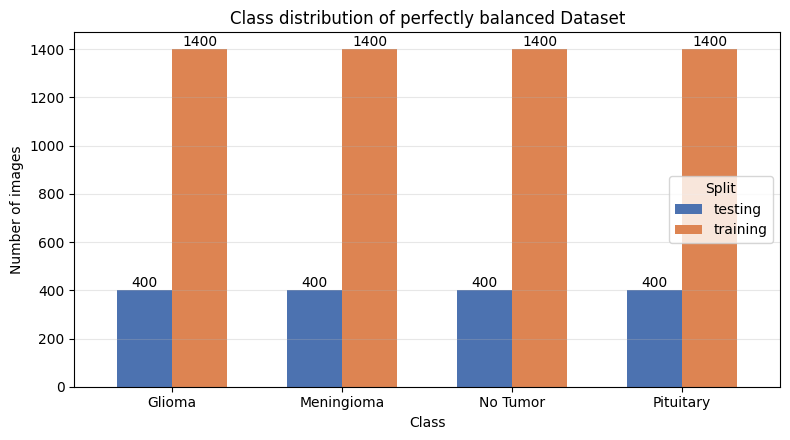

In [21]:
counts = df.groupby(['class', 'split']).size().unstack()
ax = counts.plot(kind='bar', figsize=(8, 4.5), width=0.65, color=['#4C72B0', '#DD8452'])
ax.set_title('Class distribution of perfectly balanced Dataset')
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
ax.set_xticklabels([DISPLAY_NAMES[c] for c in counts.index], rotation=0)
for container in ax.containers:
    ax.bar_label(container)
ax.legend(title='Split')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

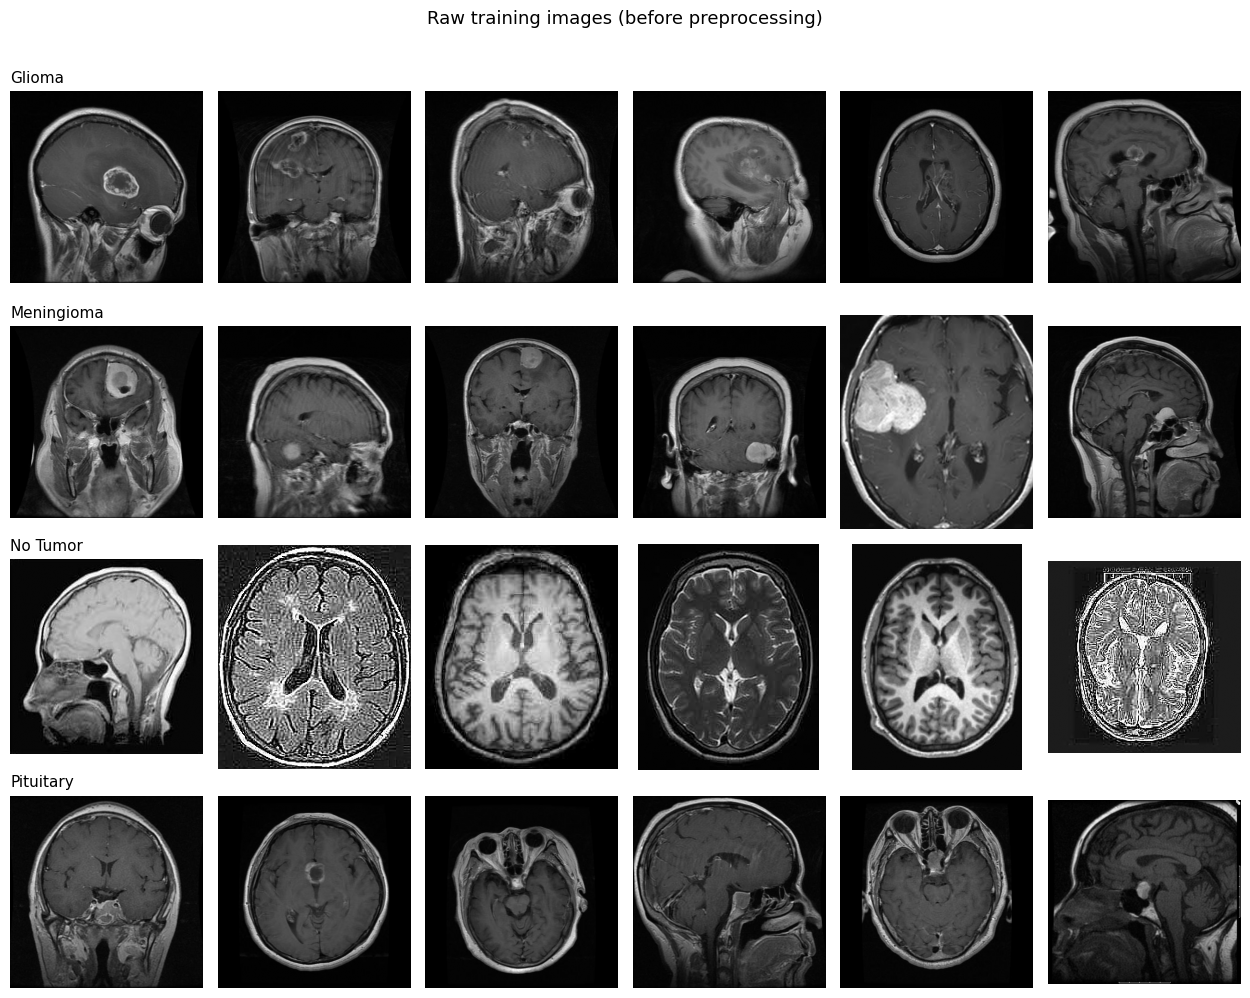

In [22]:
def show_raw_samples(classes, n=6, seed=SEED):
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(classes), n, figsize=(2.1 * n, 2.5 * len(classes)))
    for r, cls in enumerate(classes):
        paths = df[(df['split'] == 'training') & (df['class'] == cls)]['path'].tolist()
        for c, p in enumerate(rng.sample(paths, n)):
            with Image.open(p) as im:
                arr = np.array(im.convert('L'))
            axes[r, c].imshow(arr, cmap='gray')
            if c == 0:
                axes[r, c].set_title(DISPLAY_NAMES[cls], fontsize=11, loc='left')
            axes[r, c].axis('off')
    fig.suptitle('Raw training images (before preprocessing)', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


show_raw_samples(CLASS_NAMES, n=6)

Colour modes:
mode
RGB     4129
L       3067
RGBA       3
P          1

Image width  - min: 150, max: 1375
Image height - min: 167, max: 1446


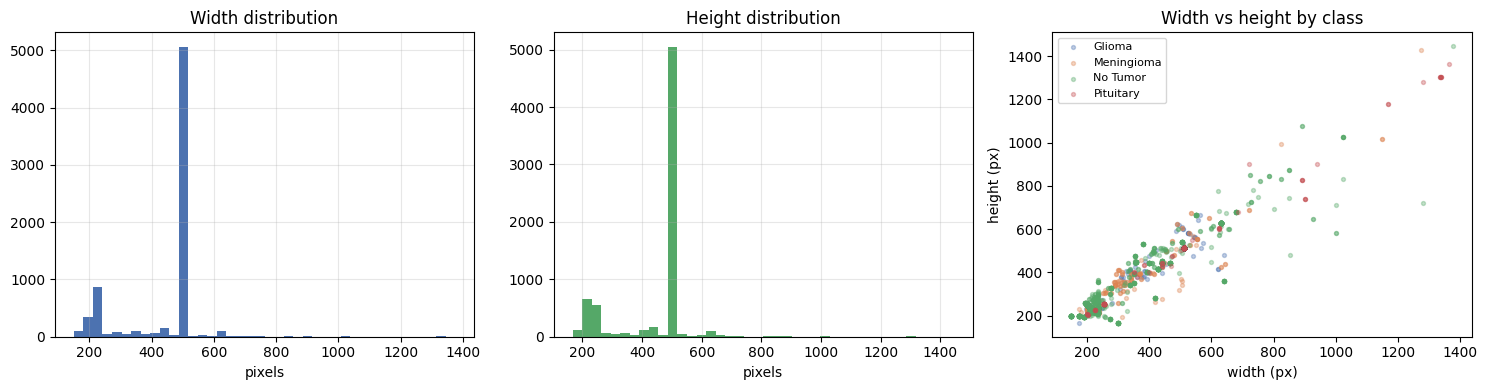

In [23]:
rows = []
for p, cls, split in zip(df['path'], df['class'], df['split']):
    with Image.open(p) as im:
        rows.append({'path': p, 'class': cls, 'split': split,
                     'width': im.size[0], 'height': im.size[1], 'mode': im.mode})
props = pd.DataFrame(rows)

print('Colour modes:')
print(props['mode'].value_counts().to_string())
print(f"\nImage width  - min: {props['width'].min():.0f}, max: {props['width'].max():.0f}")
print(f"Image height - min: {props['height'].min():.0f}, max: {props['height'].max():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(props['width'], bins=40, color='#4C72B0')
axes[0].set_title('Width distribution')
axes[1].hist(props['height'], bins=40, color='#55A868')
axes[1].set_title('Height distribution')
colors = dict(zip(CLASS_NAMES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))
for cls in CLASS_NAMES:
    sub = props[props['class'] == cls]
    axes[2].scatter(sub['width'], sub['height'], s=8, alpha=0.35,
                    color=colors[cls], label=DISPLAY_NAMES[cls])
axes[2].set_title('Width vs height by class')
axes[2].set_xlabel('width (px)')
axes[2].set_ylabel('height (px)')
axes[2].legend(fontsize=8)
for ax in axes[:2]:
    ax.set_xlabel('pixels')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

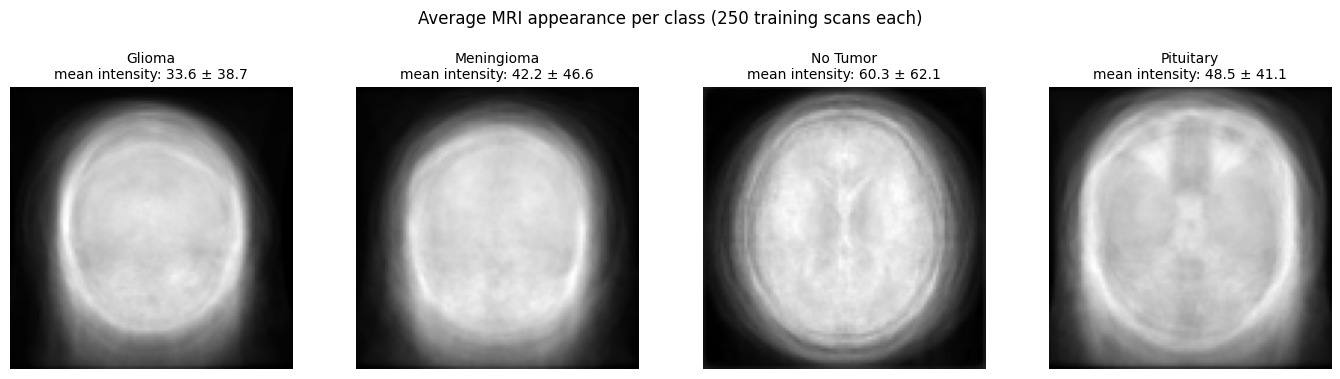

In [24]:
rng = random.Random(SEED)
AVG_SIZE = (96, 96)
avg_imgs, intensity_stats = {}, {}
for cls in CLASS_NAMES:
    paths = df[(df['split'] == 'training') & (df['class'] == cls)]['path'].tolist()
    sample = rng.sample(paths, 250)
    stack = np.stack([np.array(Image.open(p).convert('L').resize(AVG_SIZE),
                               dtype=np.float64) for p in sample])
    avg_imgs[cls] = stack.mean(axis=0)
    intensity_stats[cls] = (stack.mean(), stack.std())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, cls in zip(axes, CLASS_NAMES):
    ax.imshow(avg_imgs[cls], cmap='gray')
    ax.set_title(f"{DISPLAY_NAMES[cls]}\nmean intensity: {intensity_stats[cls][0]:.1f}"
                 f" ± {intensity_stats[cls][1]:.1f}", fontsize=10)
    ax.axis('off')
fig.suptitle('Average MRI appearance per class (250 training scans each)', y=1.04)
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Train/Validation/Test Splitting

### 4.1 Specialized preprocessing — black-margin removal

Many scans in this dataset are 512×512 images in which skull-stripping left large black margins around the brain. The dataset author explicitly recommends in kaggle margin removal before training.So, that's why I crop every image to the bounding box of non-black pixels plus a small safety margin.

### 4.2 Standard preprocessing

| Step | Value |
|---|---|
| A. Grayscale → RGB | 3 channels |
| B. Resize | 224 × 224 |
| C. Normalization | ImageNet mean / std |

### 4.3 Data augmentation

I explecitly augmented the trainin data only. For that i used standard augmentation format like:
A. RandomHorizontalFlip, p = 0.5.    B. RandomRotation to ±15°.    C. ColorJitter - brightness and contrast both 0.25.


### 4.4 Splitting strategy

- **Test set — 1,600 images:** the  {Testing/} folder. Never used for any training decision.
- **Validation set — 840 images:** a *stratified* random 15 % of {Training/}.
- **Train set — 4,760 images:** the remaining 85 %. The actual data that will used here for training the model.


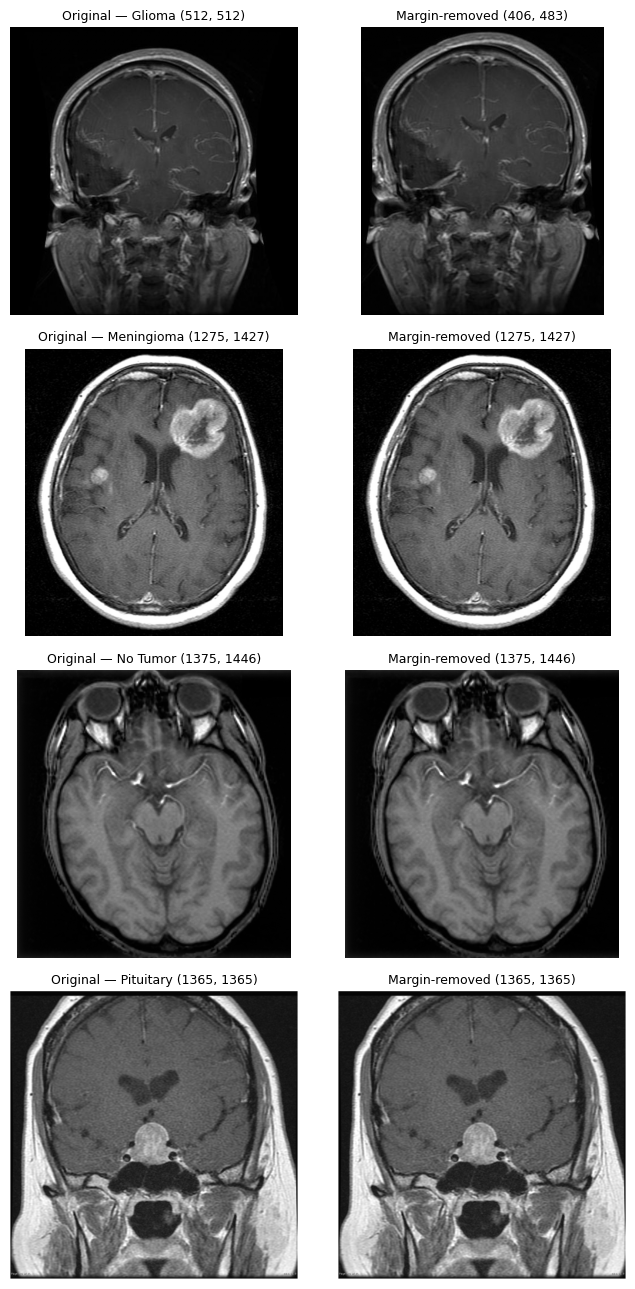

In [25]:
def crop_brain_region(img, threshold=15, pad=8):
    gray = np.array(img.convert('L'))
    mask = gray > threshold  # pixels that contain actual tissue
    if not mask.any(): # extremely dark image -> keep unchanged
        return img
    rows = np.flatnonzero(mask.any(axis=1))
    cols = np.flatnonzero(mask.any(axis=0))
    top    = max(0, rows[0] - pad)
    bottom = min(gray.shape[0] - 1, rows[-1] + pad)
    left   = max(0, cols[0] - pad)
    right  = min(gray.shape[1] - 1, cols[-1] + pad)
    return img.crop((left, top, right + 1, bottom + 1))


demo_paths = []
for cls in CLASS_NAMES:
    sub = props[(props['class'] == cls) & (props['split'] == 'training')]
    demo_paths.append(sub.sort_values(['width', 'height'], ascending=False)['path'].iloc[0])

fig, axes = plt.subplots(4, 2, figsize=(7, 13))
for r, (cls, p) in enumerate(zip(CLASS_NAMES, demo_paths)):
    with Image.open(p) as orig:
        cropped = crop_brain_region(orig)
        left_arr = np.array(orig.convert('L'))
        right_arr = np.array(cropped.convert('L'))
        orig_size, cropped_size = orig.size, cropped.size
    axes[r, 0].imshow(left_arr, cmap='gray')
    axes[r, 0].set_title(f'Original — {DISPLAY_NAMES[cls]} {orig_size}', fontsize=9)
    axes[r, 1].imshow(right_arr, cmap='gray')
    axes[r, 1].set_title(f'Margin-removed {cropped_size}', fontsize=9)
    for ax in axes[r]:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [26]:
# Image resize, augment and normalize

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['path'].to_list()
        self.labels = dataframe['label'].to_list()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as im:
            img = crop_brain_region(im).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]


# Now splitting the deataset into these 3 parts: (Train / validation / test)
train_part = df[df['split'] == 'training'].reset_index(drop=True)
test_df = df[df['split'] == 'testing'].reset_index(drop=True)

train_df, val_df = train_test_split(train_part, test_size=0.15, stratify=train_part['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Train: {len(train_df):5d} images')
print(f'Validate  : {len(val_df):5d} images')
print(f'Test : {len(test_df):5d} images')
print('\nClass distribution after splitting:')
for name, part in (('train', train_df), ('val', val_df), ('test', test_df)):
    print(f'  {name:>5}:', dict(part['class'].value_counts().sort_index()))

train_dataset = BrainMRIDataset(train_df, transform=train_transform)
val_dataset = BrainMRIDataset(val_df, transform=eval_transform)
test_dataset = BrainMRIDataset(test_df, transform=eval_transform)

BATCH_SIZE = 32
loader_gen = torch.Generator()
loader_gen.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, generator=loader_gen)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,  num_workers=2, pin_memory=True)
print(f'\nDataLoaders ready for model trining and evaluating — batch size: {BATCH_SIZE} 'f'({len(train_loader)} for train/{len(val_loader)} for validation/{len(test_loader)} for test batches)')

Train:  4760 images
Validate  :   840 images
Test :  1600 images

Class distribution after splitting:
  train: {'glioma': np.int64(1190), 'meningioma': np.int64(1190), 'notumor': np.int64(1190), 'pituitary': np.int64(1190)}
    val: {'glioma': np.int64(210), 'meningioma': np.int64(210), 'notumor': np.int64(210), 'pituitary': np.int64(210)}
   test: {'glioma': np.int64(400), 'meningioma': np.int64(400), 'notumor': np.int64(400), 'pituitary': np.int64(400)}

DataLoaders ready for model trining and evaluating — batch size: 32 (149 for train/27 for validation/50 for test batches)


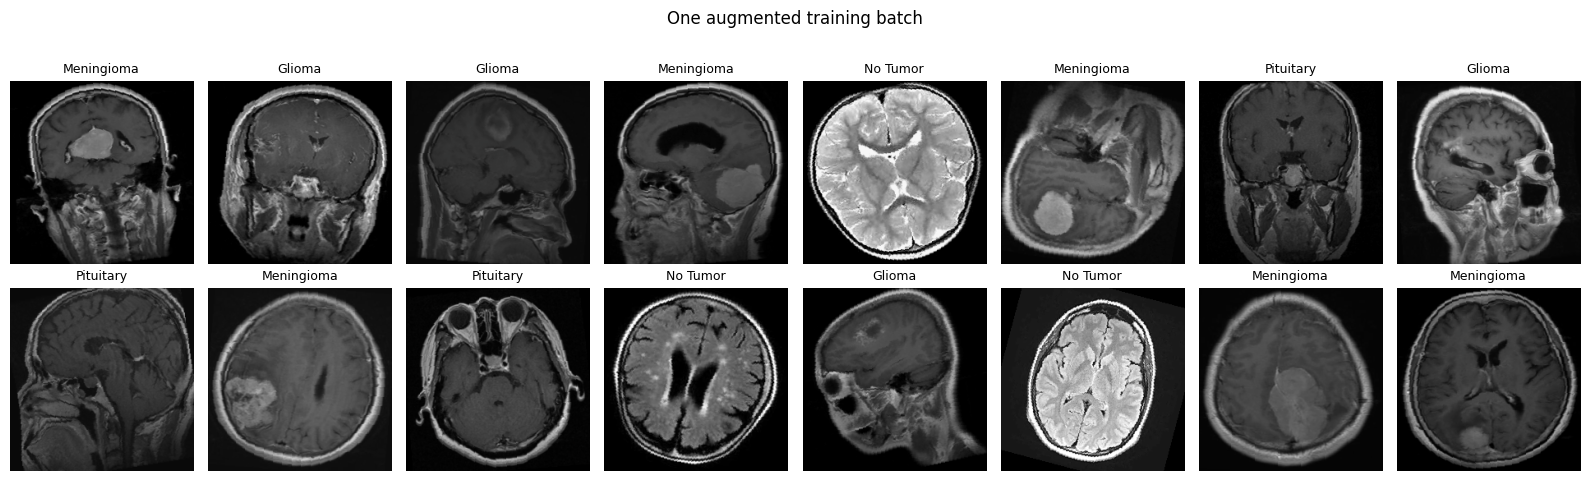

In [27]:
def denormalize(t):
    # Undo ImageNet normalization so tensors can be displayed with matplotlib
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return t * std + mean

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4.8))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(imgs[i]).permute(1, 2, 0).clamp(0, 1))
    ax.set_title(DISPLAY_NAMES[CLASS_NAMES[labels[i]]], fontsize=9)
    ax.axis('off')
fig.suptitle('One augmented training batch', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Model — EfficientNet-B0:




In [28]:
def build_model(num_classes=NUM_CLASSES, dropout=0.3):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features=1280, out_features=num_classes),)
    return model


model = build_model().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Forward-pass sanity check on the real input shape
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    print('Output shape for a batch of 2 images:', tuple(model(dummy).shape))

model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 108MB/s] 


Total parameters    : 4,012,672
Trainable parameters: 4,012,672
Output shape for a batch of 2 images: (2, 4)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

---
## 6. Training the Model:

| process name | values |
|---|---|
| Loss | `CrossEntropyLoss(label_smoothing=0.1)` |
| Optimizer | `AdamW`, weight decay 1e-4 |
| **Phase A** | 3 epochs, backbone **frozen**, lr = 1e-3 |
| **Phase B** | up to 25 epochs, **all layers unfrozen**, lr = 2e-4 |



In [29]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  training', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)
    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  evaluating', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        seen += labels.size(0)
    return running_loss / seen, correct / seen


In [30]:
PHASE_A_EPOCHS = 3      # frozen backbone
PHASE_B_EPOCHS = 25     # full fine-tuning
PATIENCE = 6            # epochs without val-loss improvement before stopping the model training
BEST_MODEL_PATH = 'best_efficientnet_b0_brain_mri.pth'

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
epochs_since_improvement = 0


def log_epoch(phase, epoch, tr_loss, tr_acc, va_loss, va_acc, lr):
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(lr)
    print(f'[{phase:>7}] epoch {epoch:02d} | lr {lr:.2e} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.4f}')


start = time.time()
epoch = 0

# Phase A: freeze the convolutional backbone, train the new head for warming up.
for p in model.features.parameters():
    p.requires_grad = False
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=1e-3, weight_decay=1e-4)

for _ in range(PHASE_A_EPOCHS):
    epoch += 1
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_acc = evaluate(model, val_loader)
    log_epoch('phase A', epoch, tr_loss, tr_acc, va_loss, va_acc,
              optimizer.param_groups[0]['lr'])
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

#Phase B: unfreeze everything and fine-tune at a lower learning rate to get maximum accuracy
for p in model.parameters():
    p.requires_grad = True
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.3, patience=2)
UNFREEZE_EPOCH = epoch

for _ in range(PHASE_B_EPOCHS):
    epoch += 1
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_acc = evaluate(model, val_loader)
    scheduler.step(va_loss)
    log_epoch('phase B', epoch, tr_loss, tr_acc, va_loss, va_acc,
              optimizer.param_groups[0]['lr'])

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        epochs_since_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(no val-loss improvement for {PATIENCE} epochs).')
            break


model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True))
minutes = (time.time() - start) / 60
print(f'\nTraining finished in {minutes:.1f} min | best val loss {best_val_loss:.4f} | '
      f'best val acc {max(history["val_acc"]):.4f}')

  training:   0%|          | 0/149 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/27 [00:00<?, ?it/s]

[phase A] epoch 01 | lr 1.00e-03 | train loss 0.8640 acc 0.7508 | val loss 0.6820 acc 0.8512


  training:   0%|          | 0/149 [00:00<?, ?it/s]

  evaluating:   0%|          | 0/27 [00:00<?, ?it/s]

...

[phase B] epoch 27 | lr 1.80e-05 | train loss 0.3555 acc 0.9994 | val loss 0.3593 acc 0.9964


  training:   0%|          | 0/149 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b06476d6d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1675, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b06476d6d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1675, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

  evaluating:   0%|          | 0/27 [00:00<?, ?it/s]

[phase B] epoch 28 | lr 5.40e-06 | train loss 0.3556 acc 0.9992 | val loss 0.3590 acc 0.9964

Early stopping at epoch 28 (no val-loss improvement for 6 epochs).

Training finished in 24.4 min | best val loss 0.3578 | best val acc 0.9976


---
## 7. Training / Validation Curves


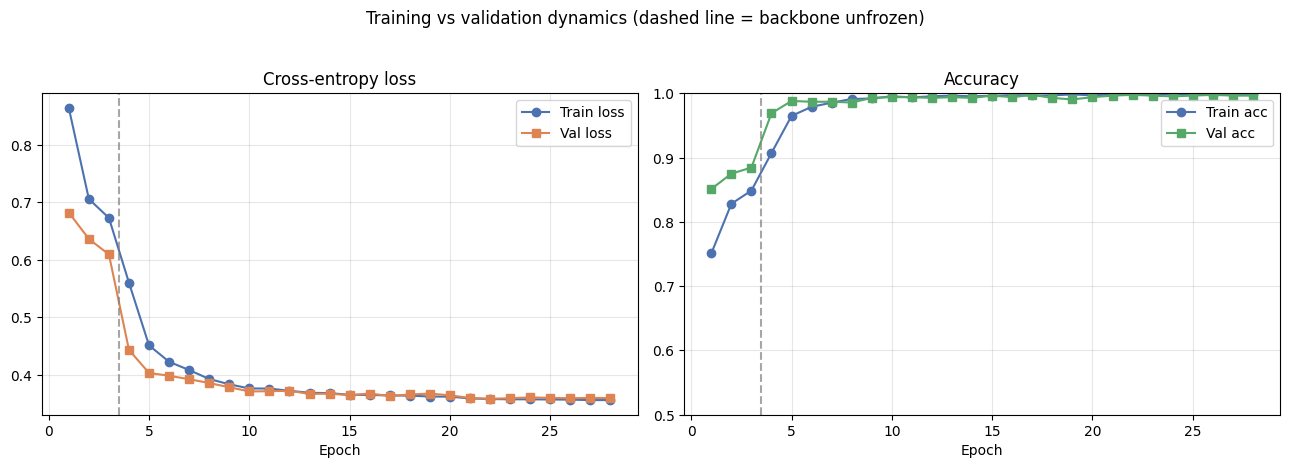

In [31]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#4C72B0', label='Train loss')
axes[0].plot(epochs_range, history['val_loss'], 's-', color='#DD8452', label='Val loss')
axes[0].axvline(UNFREEZE_EPOCH + 0.5, linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('Cross-entropy loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'o-', color='#4C72B0', label='Train acc')
axes[1].plot(epochs_range, history['val_acc'], 's-', color='#55A868', label='Val acc')
axes[1].axvline(UNFREEZE_EPOCH + 0.5, linestyle='--', color='gray', alpha=0.7)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(min(0.5, min(history['train_acc']) - 0.05), 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Training vs validation dynamics (dashed line = backbone unfrozen)', y=1.03)
plt.tight_layout()
plt.show()

---
## 8. Evaluation of model train test set


In [32]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    for images, labels in tqdm(loader, desc='predicting', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        probs = torch.softmax(model(images), dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(probs.argmax(dim=1).cpu().numpy())
        y_proba.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_proba)


test_loss, test_acc = evaluate(model, test_loader)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f} '
      f'({test_acc * 100:.2f}%)')

y_true, y_pred, y_proba = predict_all(model, test_loader)

  evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Test loss: 0.4581 | Test accuracy: 0.9606 (96.06%)


predicting:   0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b06476d6d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1675, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b06476d6d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1675, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

In [33]:
target_names = [DISPLAY_NAMES[c] for c in CLASS_NAMES]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

              precision    recall  f1-score   support

      Glioma     0.9971    0.8525    0.9191       400
  Meningioma     0.9103    0.9900    0.9485       400
    No Tumor     0.9524    1.0000    0.9756       400
   Pituitary     0.9926    1.0000    0.9963       400

    accuracy                         0.9606      1600
   macro avg     0.9631    0.9606    0.9599      1600
weighted avg     0.9631    0.9606    0.9599      1600



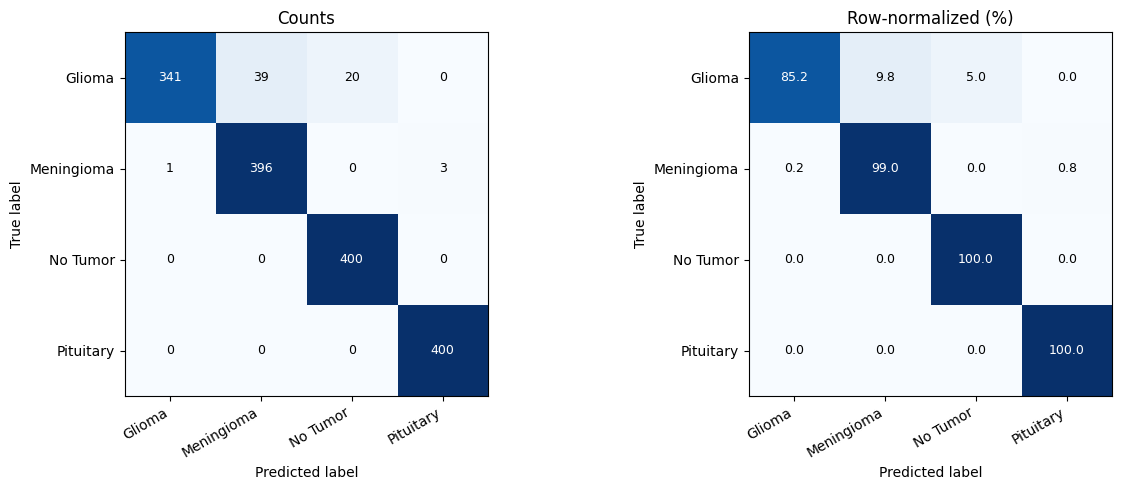

In [34]:
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, matrix, title, fmt in ((axes[0], cm, 'Counts', 'd'),
                               (axes[1], cm_pct, 'Row-normalized (%)', '.1f')):
    ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(target_names, rotation=30, ha='right')
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)
    thresh = matrix.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(matrix[i, j], fmt), ha='center', va='center',
                    color='white' if matrix[i, j] > thresh else 'black', fontsize=9)
plt.tight_layout()
plt.show()

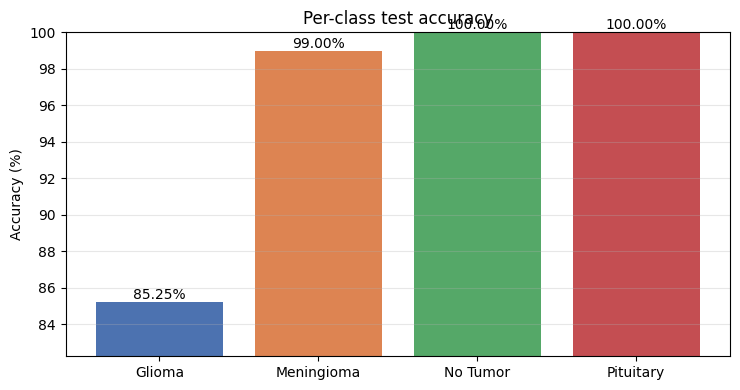

In [35]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(target_names, per_class_acc,
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.bar_label(bars, fmt='%.2f%%')
ax.set_ylim(min(90, per_class_acc.min() - 3), 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class test accuracy')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Sample Predictions & Error Analysis


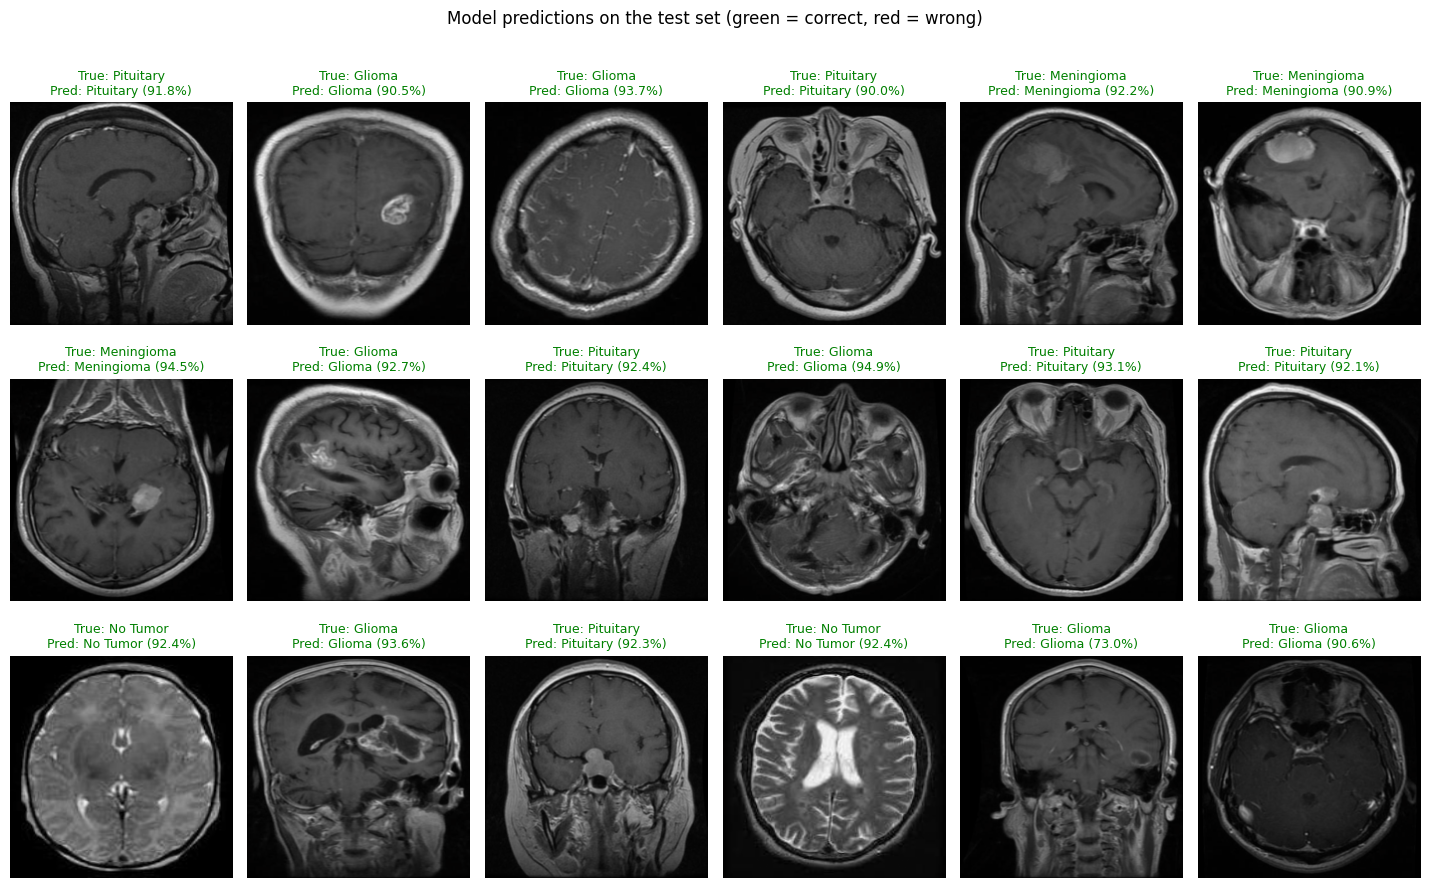

In [36]:
def show_test_predictions(indices, ncols=6, title=''):
    nrows = math.ceil(len(indices) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 3.0 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, idx in zip(axes, indices):
        img, label = test_dataset[idx]                 # deterministic eval transform
        prob = y_proba[idx]
        pred = int(np.argmax(prob))
        ok = (pred == label)
        ax.imshow(denormalize(img).permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f'True: {DISPLAY_NAMES[CLASS_NAMES[label]]}\n'
                     f'Pred: {DISPLAY_NAMES[CLASS_NAMES[pred]]} ({prob[pred] * 100:.1f}%)',
                     fontsize=9, color='green' if ok else 'red')
        ax.axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


rng = random.Random(SEED)
sample_idx = rng.sample(range(len(test_dataset)), 18)
show_test_predictions(sample_idx, ncols=6,
                      title='Model predictions on the test set (green = correct, red = wrong)')

Misclassified test images: 63 / 1600 (3.94%)


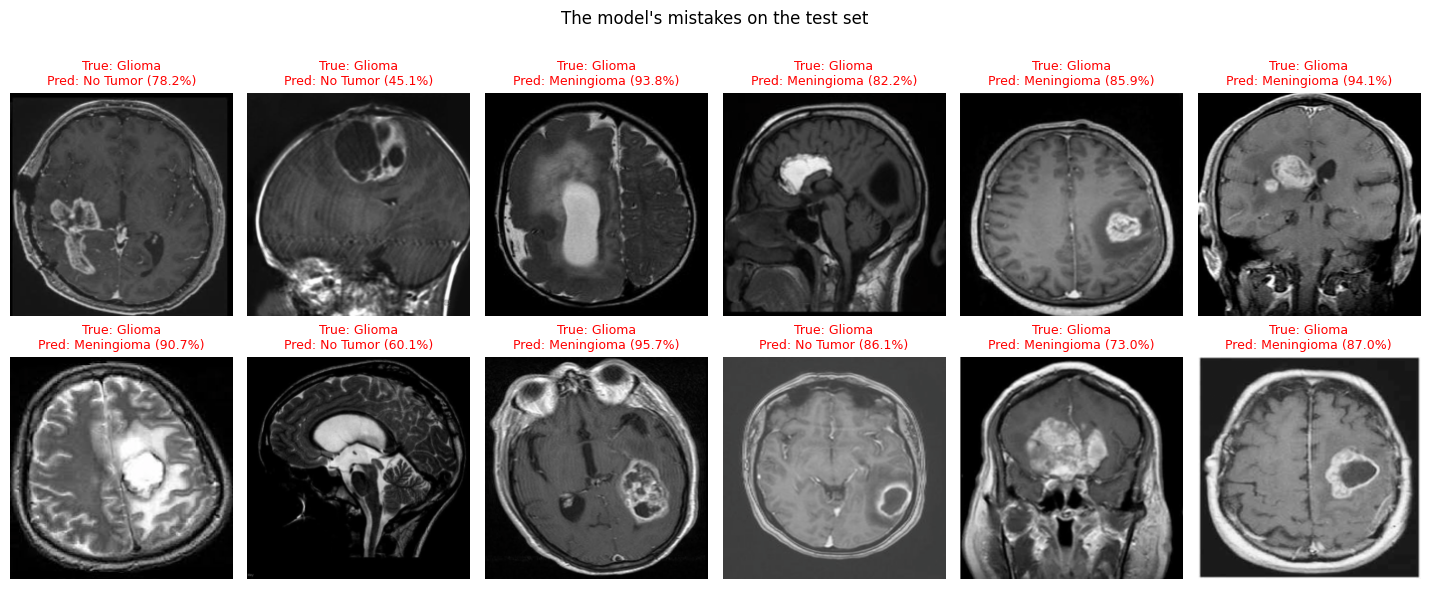

In [37]:
wrong_idx = np.flatnonzero(y_pred != y_true)
print(f'Misclassified test images: {len(wrong_idx)} / {len(y_true)} '
      f'({len(wrong_idx) / len(y_true) * 100:.2f}%)')

if len(wrong_idx) > 0:
    show_test_predictions(list(wrong_idx[:min(12, len(wrong_idx))]), ncols=6,
                          title='The model\'s mistakes on the test set')

---
## 10. Model Interpretability — Grad-CAM & Score-CAM


In [38]:
class GradCAM:
    # Gradient-weighted Class Activation Mapping for a single target layer.
    def __init__(self, model, target_layer):
        self.model = model
        self.stored = {}
        target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, module_in, module_out):
        self.stored['activation'] = module_out
        # tensor-level hook; guarded so Score-CAM's no-grad passes skip it safely
        if module_out.requires_grad:
            module_out.register_hook(lambda grad: self.stored.__setitem__('gradient', grad))

    def heat_map(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward()

        act = self.stored['activation']          # (1, C, 7, 7)
        grad = self.stored['gradient']           # (1, C, 7, 7)
        weights = grad.mean(dim=(2, 3), keepdim=True)      # channel importance
        cam = torch.relu((weights * act).sum(dim=1)).squeeze(0)   # (7, 7)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        cam = F.interpolate(cam[None, None], size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        # FIX APPLIED HERE: Added .detach() before converting to numpy
        return cam.squeeze().detach().cpu().numpy(), class_idx

grad_cam = GradCAM(model, model.features[-1])   # last MBConv stage
print('Grad-CAM ready (gradient-based).')

Grad-CAM ready (gradient-based).


In [39]:
class ScoreCAM:
    # Gradient-free Class Activation Mapping (Wang et al., 2020).
    # Channel weights are measured from the model's own confidence on
    # masked inputs, so no gradients are involved anywhere.
    def __init__(self, model, target_layer):
        self.model = model
        self.stored = {}
        target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, module_in, module_out):
        self.stored['activation'] = module_out.detach()

    @torch.no_grad()
    def heat_map(self, input_tensor, class_idx=None, batch_size=64):
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        act = self.stored['activation'][0]                   # (C, 7, 7)
        num_channels = act.shape[0]

        # upsample every channel map to input size, min-max normalize -> masks
        maps = F.interpolate(act[None], size=(IMG_SIZE, IMG_SIZE),
                             mode='bilinear', align_corners=False)[0]
        flat = maps.flatten(1)
        mn = flat.min(dim=1).values[:, None, None]
        mx = flat.max(dim=1).values[:, None, None]
        masks = (maps - mn) / (mx - mn + 1e-8)               # (C, 224, 224)

        # re-score each masked input in batches; weight = model confidence
        scores = []
        for i in range(0, num_channels, batch_size):
            # FIX APPLIED HERE: Added .unsqueeze(1) to match the 3 RGB channels
            mask_batch = masks[i:i + batch_size].unsqueeze(1)
            masked = input_tensor * mask_batch
            scores.append(torch.softmax(self.model(masked), dim=1)[:, class_idx])

        scores = torch.cat(scores)
        weights = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

        cam = torch.relu((weights[:, None, None] * act).sum(dim=0))    # (7, 7)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        cam = F.interpolate(cam[None, None], size=(IMG_SIZE, IMG_SIZE),
                            mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx


score_cam = ScoreCAM(model, model.features[-1])   # last MBConv stage
print('Score-CAM ready (gradient-free).')

Score-CAM ready (gradient-free).


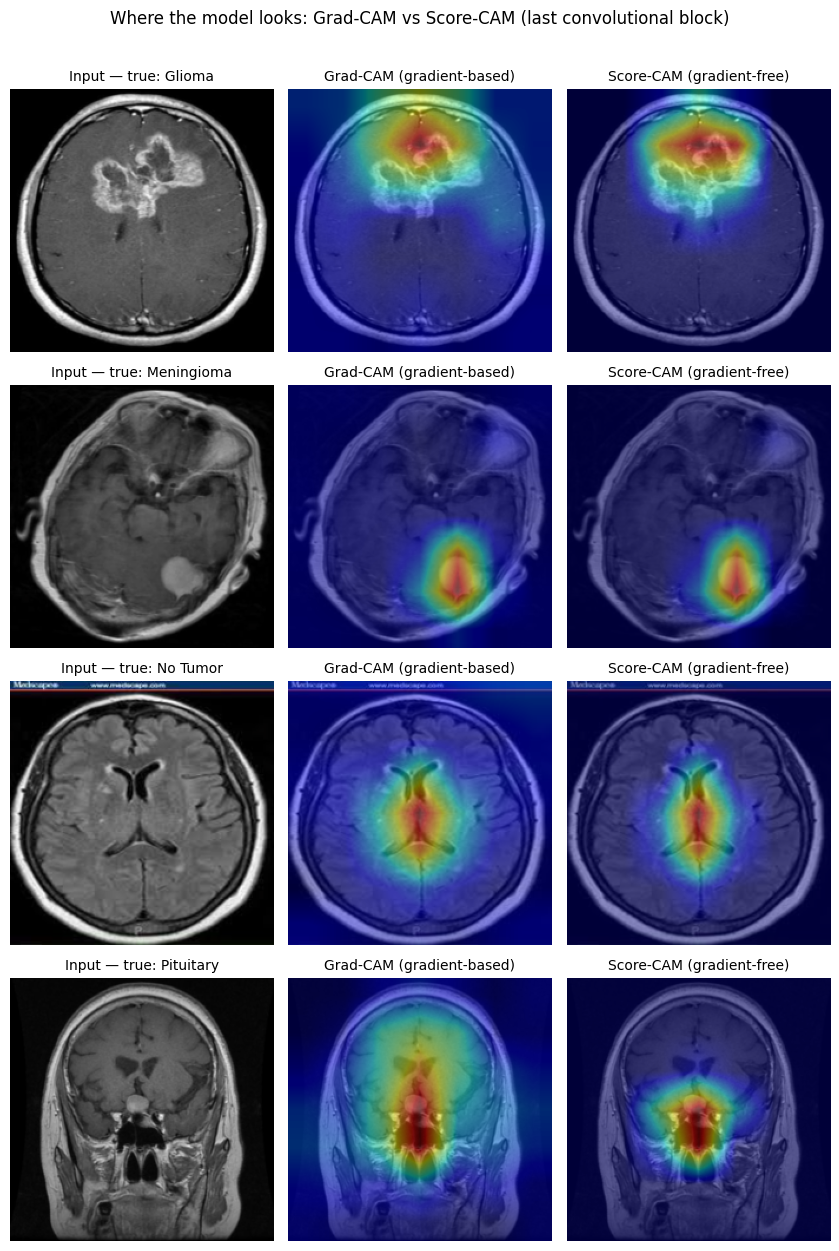

In [40]:
# One correctly-classified test scan per class
picked = []
for cls_label in range(NUM_CLASSES):
    for idx in np.flatnonzero((y_true == cls_label) & (y_pred == cls_label)):
        picked.append(int(idx))
        break

fig, axes = plt.subplots(len(picked), 3, figsize=(8.5, 3.1 * len(picked)))
axes = np.atleast_2d(axes)
for r, idx in enumerate(picked):
    img_tensor, label = test_dataset[idx]
    target = int(label)
    cam_grad, _ = grad_cam.heat_map(img_tensor[None].to(DEVICE), class_idx=target)
    cam_score, _ = score_cam.heat_map(img_tensor[None].to(DEVICE), class_idx=target)
    base = denormalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()

    axes[r, 0].imshow(base)
    axes[r, 0].set_title(f'Input — true: {DISPLAY_NAMES[CLASS_NAMES[label]]}', fontsize=10)
    axes[r, 1].imshow(base)
    axes[r, 1].imshow(cam_grad, cmap='jet', alpha=0.45)
    axes[r, 1].set_title('Grad-CAM (gradient-based)', fontsize=10)
    axes[r, 2].imshow(base)
    axes[r, 2].imshow(cam_score, cmap='jet', alpha=0.45)
    axes[r, 2].set_title('Score-CAM (gradient-free)', fontsize=10)
    for ax in axes[r]:
        ax.axis('off')
fig.suptitle('Where the model looks: Grad-CAM vs Score-CAM (last convolutional block)',
             y=1.01)
plt.tight_layout()
plt.show()